In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import datetime

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Proyecto/Estadísticas Jugadores Base ACB.xlsx'

In [ ]:
xls = pd.ExcelFile(file_path)

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Proyecto/Estadísticas Jugadores Base ACB.xlsx', header=0)

In [ ]:
df["Impact Score"] = (
    df["Valoración"] * 0.50 +
    df["Asistencias"] * 0.25 +
    df["Puntos"] * 0.15 +
    df["Recuperaciones"] * 0.10
)

df = df.sort_values("Impact Score", ascending=False)

df["Rank"] = range(1, len(df) + 1)

df[["Rank","Jugador","Equipo","Impact Score"]]

,Rank,Jugador,Equipo,Impact Score
2,1,Trent Forrest,Baskonia,12.565
8,2,Ricky Rubio,Joventut Badalona,12.015
1,3,Marcelinho Huertas,Laguna Tenerife,11.855
0,4,Jean Montero,Valencia Basket,11.415
6,5,Melwin Pantzar,Bilbao Basket,11.365
5,6,Shannon Evans,MoraBanc Andorra,10.655
7,7,Otis Livingston,Basquet Girona,9.805
9,8,Kendrick Perry,Unicaja,9.730
4,9,Trae Bell-Haynes,Casademont Zaragoza,9.580
3,10,Facu Campazzo,Real Madrid,8.240


In [ ]:
df.to_excel("acb_point_guards_impact_ranking.xlsx", index=False)

In [ ]:
from google.colab import files

files.download("acb_point_guards_impact_ranking.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

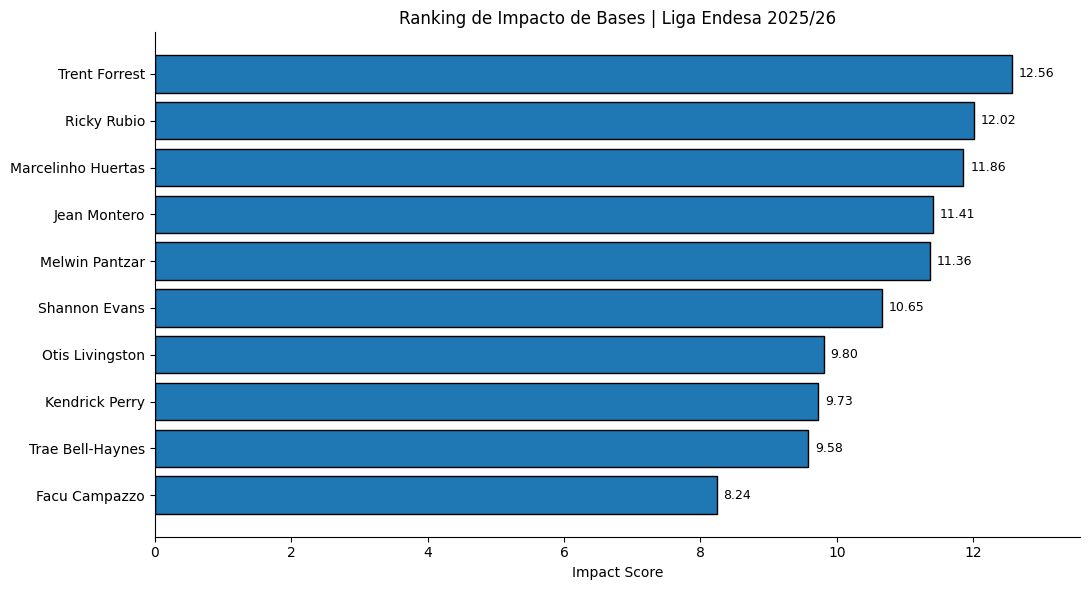

In [ ]:
top10 = df.sort_values("Impact Score", ascending=False)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top10["Jugador"],
    top10["Impact Score"],
    edgecolor="black",
    linewidth=1
)

plt.xlabel("Impact Score")
plt.ylabel("")
plt.title("Ranking de Impacto de Bases | Liga Endesa 2025/26")

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.10,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=9
    )

plt.xlim(0, top10["Impact Score"].max() + 1)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("acb_impact_score_ranking.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
team_colors = {
    "Real Madrid": "#FFFFFF",        # Blanco
    "Valencia Basket": "#FF7F00",    # Naranja
    "La Laguna Tenerife": "#FFD100", # Amarillo
    "Joventut Badalona": "#00843D",  # Verde
    "Unicaja": "#006B3F",            # Verde oscuro
    "Baxi Manresa": "#C00000",       # Rojo
    "Gran Canaria": "#FFD100",       # Amarillo
    "UCAM Murcia": "#7A0019",        # Granate
    "Baskonia": "#003B7A",           # Azul oscuro
    "Casademont Zaragoza": "#E30613" # Rojo
}

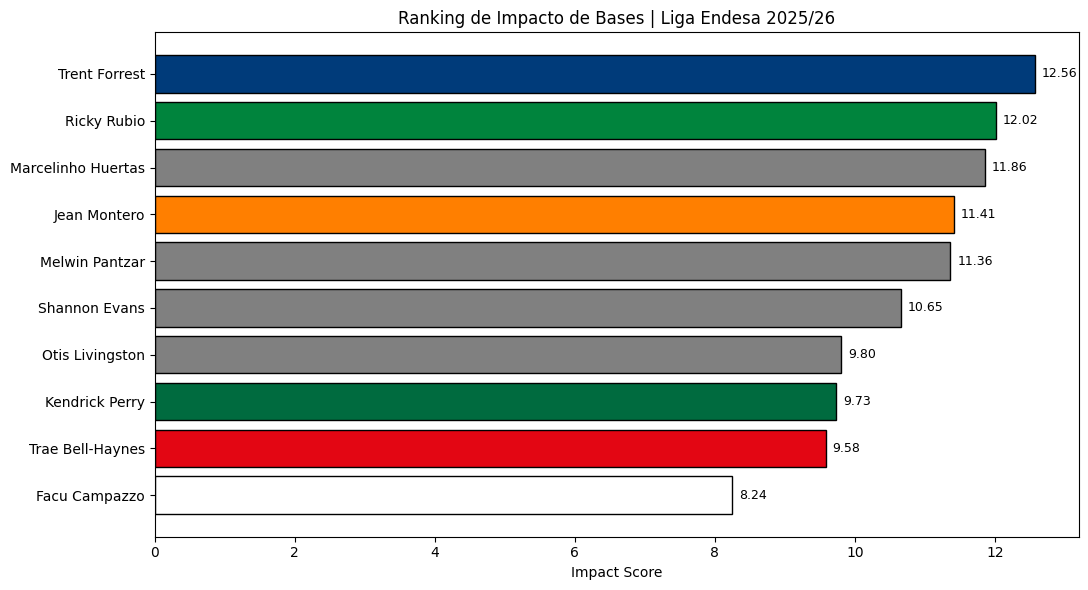

In [ ]:
colors = [team_colors.get(team, "#808080") for team in top10["Equipo"]]

plt.figure(figsize=(11,6))

bars = plt.barh(
    top10["Jugador"],
    top10["Impact Score"],
    color=colors,
    edgecolor="black",
    linewidth=1
)

plt.xlabel("Impact Score")
plt.ylabel("")
plt.title("Ranking de Impacto de Bases | Liga Endesa 2025/26")

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.10,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [ ]:
print(df["Equipo"].unique())

['Baskonia' 'Joventut Badalona' 'Laguna Tenerife' 'Valencia Basket'
 'Bilbao Basket' 'MoraBanc Andorra' 'Basquet Girona' 'Unicaja'
 'Casademont Zaragoza' 'Real Madrid']


In [ ]:
team_colors = {
    "Baskonia": "#003B7A",
    "Joventut Badalona": "#00843D",
    "Laguna Tenerife": "#FFD100",
    "Valencia Basket": "#FF7F00",
    "Bilbao Basket": "#000000",
    "MoraBanc Andorra": "#005BAC",
    "Basquet Girona": "#D71920",
    "Unicaja": "#006B3F",
    "Casademont Zaragoza": "#E30613",
    "Real Madrid": "#FFFFFF"
}

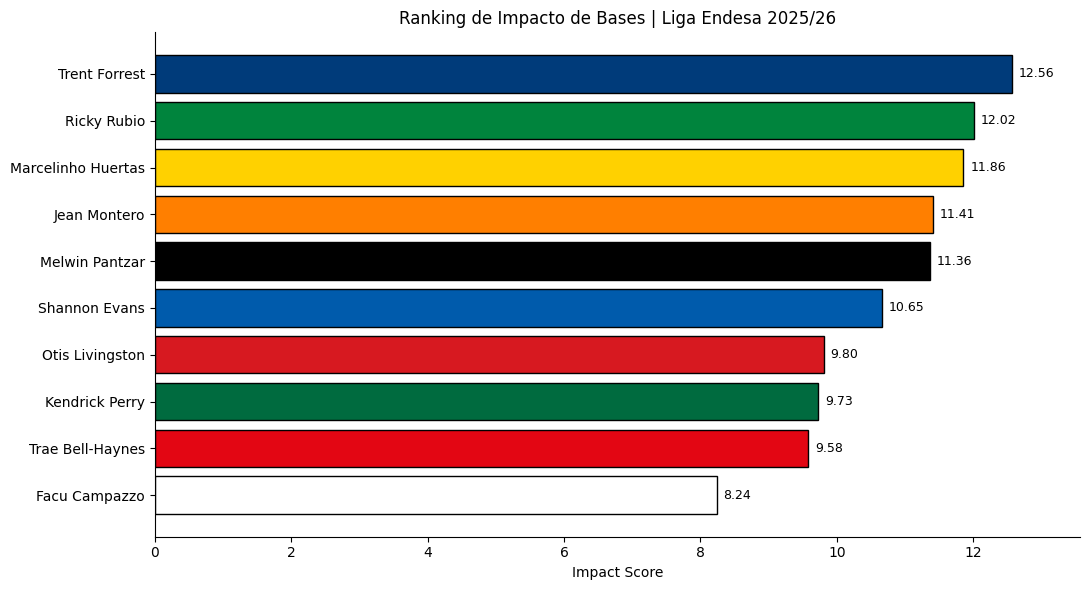

In [ ]:
colors = [team_colors.get(team, "#808080") for team in top10["Equipo"]]

plt.figure(figsize=(11,6))

bars = plt.barh(
    top10["Jugador"],
    top10["Impact Score"],
    color=colors,
    edgecolor="black",
    linewidth=1
)

plt.xlabel("Impact Score")
plt.ylabel("")
plt.title("Ranking de Impacto de Bases | Liga Endesa 2025/26")

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.10,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center",
        fontsize=9
    )

plt.xlim(0, top10["Impact Score"].max() + 1)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("acb_impact_score_ranking.png", dpi=300, bbox_inches="tight")
plt.show()